# SpaceX Falcon 9 First Stage Landing Prediction
## Lab 5: Exploratory Data Analysis with Data Visualization

We use scatter plots, bar charts and line charts to explore how flight number, payload mass, launch site, orbit and time relate to landing success, and then prepare one-hot encoded features for machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
palette = {0: "#d62728", 1: "#2ca02c"}

In [2]:
df = pd.read_csv("dataset_part_2.csv")
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


### Flight Number vs. Payload Mass

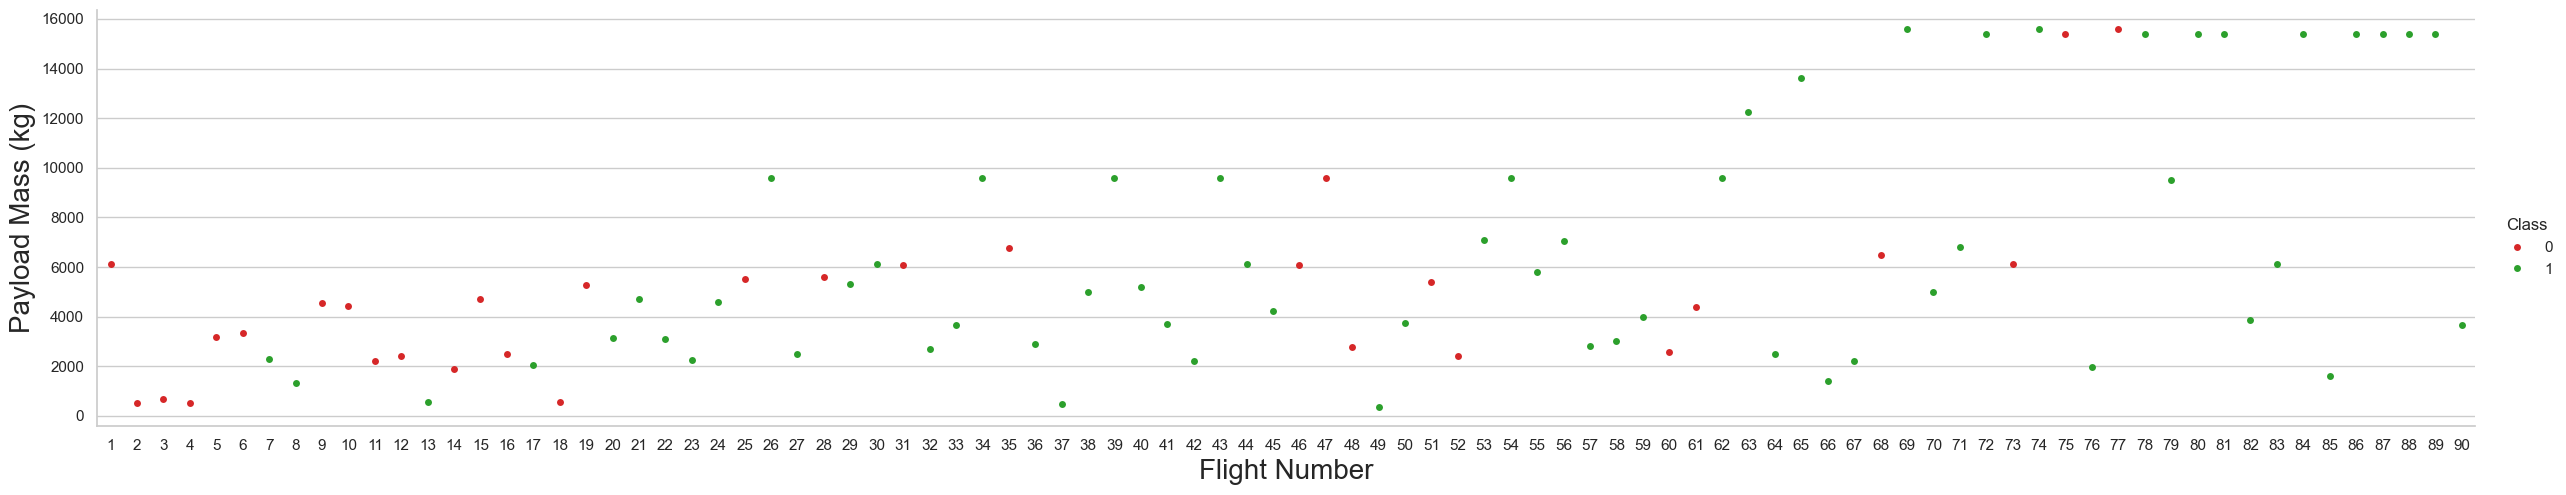

In [3]:
g = sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect=5, palette=palette)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Payload Mass (kg)", fontsize=20)
plt.savefig("images/eda_flight_vs_payload.png", dpi=150, bbox_inches="tight")
plt.show()

Later flights are more likely to land successfully, and heavier payloads do not stop the first stage from landing.

### Task 1: Visualize the relationship between Flight Number and Launch Site

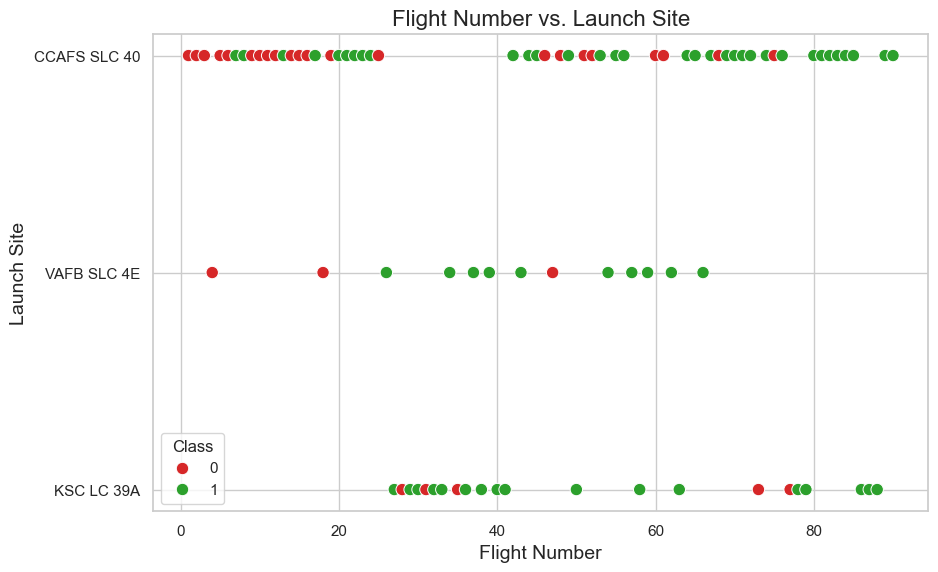

In [4]:
plt.figure(figsize=(10, 6.2))
sns.scatterplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, palette=palette, s=80)
plt.xlabel("Flight Number", fontsize=14)
plt.ylabel("Launch Site", fontsize=14)
plt.title("Flight Number vs. Launch Site", fontsize=16)
plt.savefig("images/eda_flight_vs_site.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 2: Visualize the relationship between Payload Mass and Launch Site

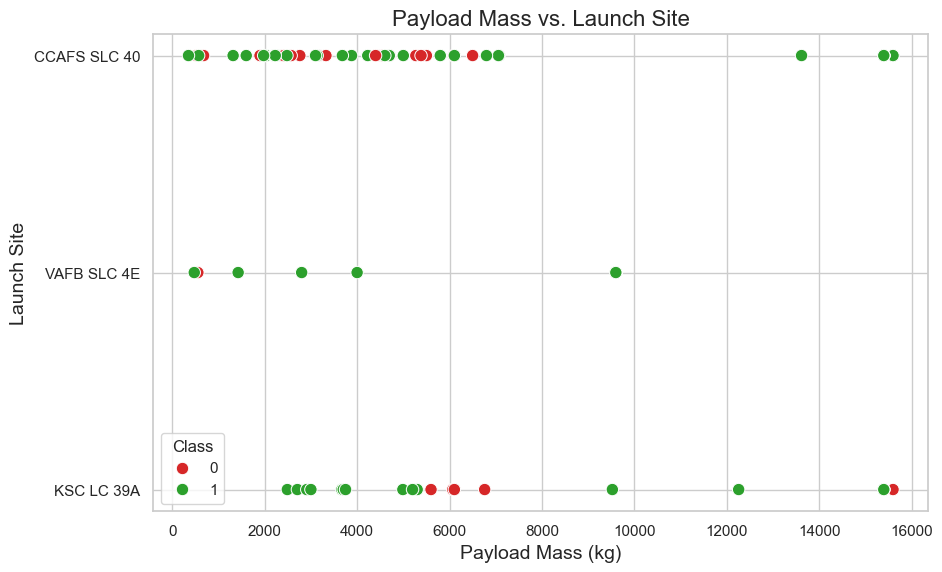

In [5]:
plt.figure(figsize=(10, 6.2))
sns.scatterplot(x="PayloadMass", y="LaunchSite", hue="Class", data=df, palette=palette, s=80)
plt.xlabel("Payload Mass (kg)", fontsize=14)
plt.ylabel("Launch Site", fontsize=14)
plt.title("Payload Mass vs. Launch Site", fontsize=16)
plt.savefig("images/eda_payload_vs_site.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 3: Visualize the relationship between success rate of each orbit type

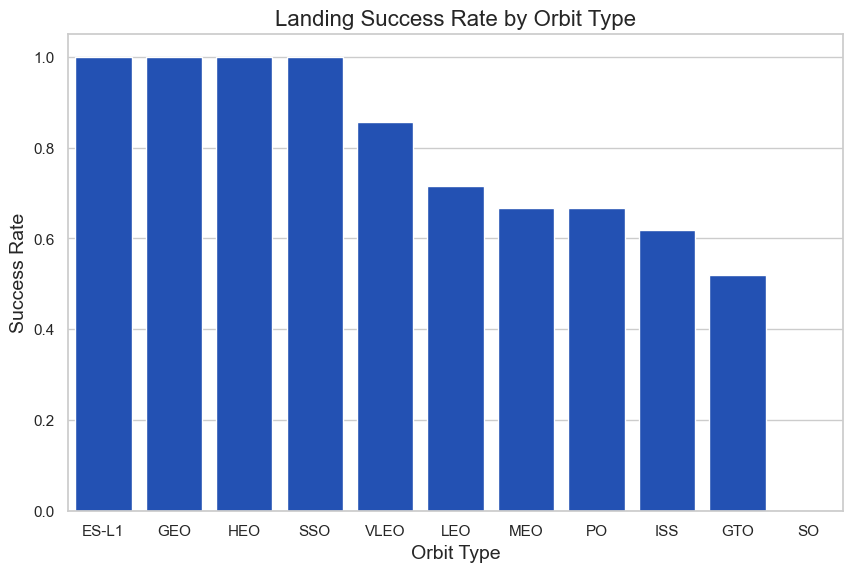

,Orbit,Class
0,ES-L1,1.000000
1,GEO,1.000000
2,HEO,1.000000
3,SSO,1.000000
4,VLEO,0.857143
5,LEO,0.714286
6,MEO,0.666667
7,PO,0.666667
8,ISS,0.619048
9,GTO,0.518519


In [6]:
orbit_success = df.groupby("Orbit")["Class"].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(10, 6.2))
sns.barplot(x="Orbit", y="Class", data=orbit_success, color="#0B49CB")
plt.xlabel("Orbit Type", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Landing Success Rate by Orbit Type", fontsize=16)
plt.savefig("images/eda_orbit_success.png", dpi=150, bbox_inches="tight")
plt.show()
orbit_success

### Task 4: Visualize the relationship between Flight Number and Orbit type

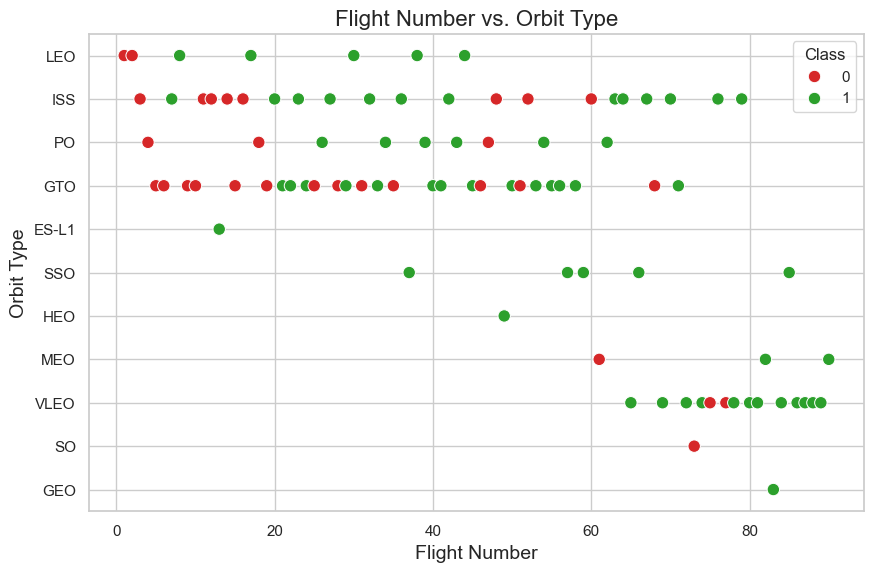

In [7]:
plt.figure(figsize=(10, 6.2))
sns.scatterplot(x="FlightNumber", y="Orbit", hue="Class", data=df, palette=palette, s=80)
plt.xlabel("Flight Number", fontsize=14)
plt.ylabel("Orbit Type", fontsize=14)
plt.title("Flight Number vs. Orbit Type", fontsize=16)
plt.savefig("images/eda_flight_vs_orbit.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 5: Visualize the relationship between Payload Mass and Orbit type

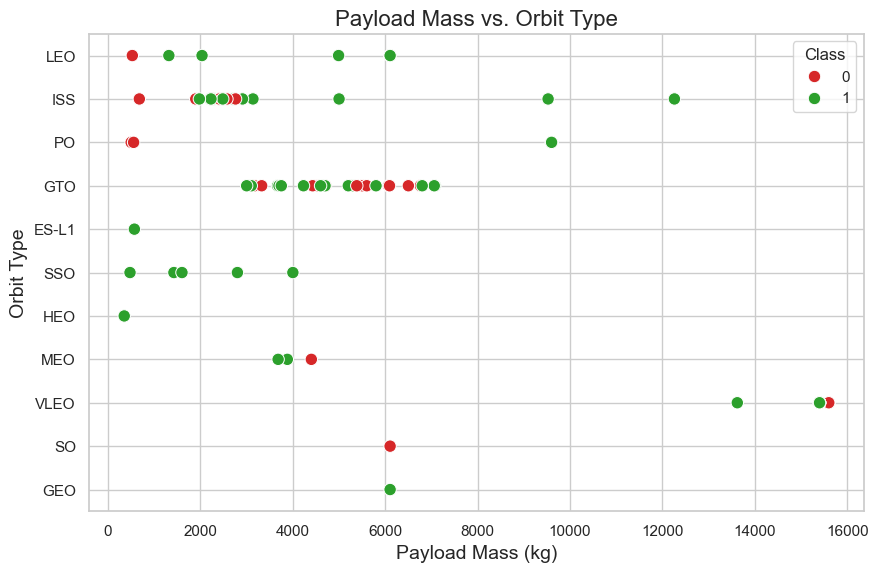

In [8]:
plt.figure(figsize=(10, 6.2))
sns.scatterplot(x="PayloadMass", y="Orbit", hue="Class", data=df, palette=palette, s=80)
plt.xlabel("Payload Mass (kg)", fontsize=14)
plt.ylabel("Orbit Type", fontsize=14)
plt.title("Payload Mass vs. Orbit Type", fontsize=16)
plt.savefig("images/eda_payload_vs_orbit.png", dpi=150, bbox_inches="tight")
plt.show()

### Task 6: Visualize the launch success yearly trend

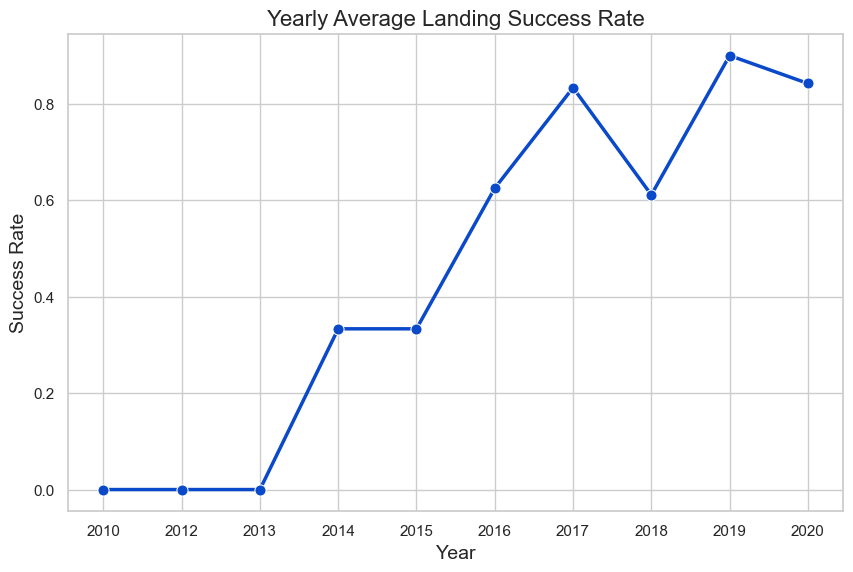

,Year,Class
0,2010,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.333333
4,2015,0.333333
5,2016,0.625000
6,2017,0.833333
7,2018,0.611111
8,2019,0.900000
9,2020,0.842105


In [9]:
def Extract_year(dates):
    return [d.split("-")[0] for d in dates]

df["Year"] = Extract_year(df["Date"])
yearly = df.groupby("Year")["Class"].mean().reset_index()
plt.figure(figsize=(10, 6.2))
sns.lineplot(x="Year", y="Class", data=yearly, marker="o", linewidth=2.5, color="#0B49CB", markersize=8)
plt.xlabel("Year", fontsize=14)
plt.ylabel("Success Rate", fontsize=14)
plt.title("Yearly Average Landing Success Rate", fontsize=16)
plt.savefig("images/eda_yearly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
yearly

## Additional Insights: What Drives a Successful Landing?
Beyond the standard tasks, we look at the booster hardware, booster reuse, landing type and SpaceX's experience over time.

In [10]:
df['LandingType'] = df['Outcome'].str.split(' ').str[1].replace({'ASDS': 'Drone ship (ASDS)', 'RTLS': 'Ground pad (RTLS)', 'Ocean': 'Ocean', 'None': 'No attempt'})
df['LandingAttempted'] = ~df['Outcome'].str.startswith('None')
failures = df[df['Class'] == 0]
print('Failed outcomes (Class = 0):', len(failures))
print('  of which no landing was attempted:', (~failures['LandingAttempted']).sum())
print('  of which a landing was attempted but failed:', failures['LandingAttempted'].sum())
attempted = df[df['LandingAttempted']]
print('Success rate when a landing is attempted:', round(attempted['Class'].mean(), 3), 'over', len(attempted), 'attempts')

Failed outcomes (Class = 0): 30
  of which no landing was attempted: 21
  of which a landing was attempted but failed: 9
Success rate when a landing is attempted: 0.87 over 69 attempts


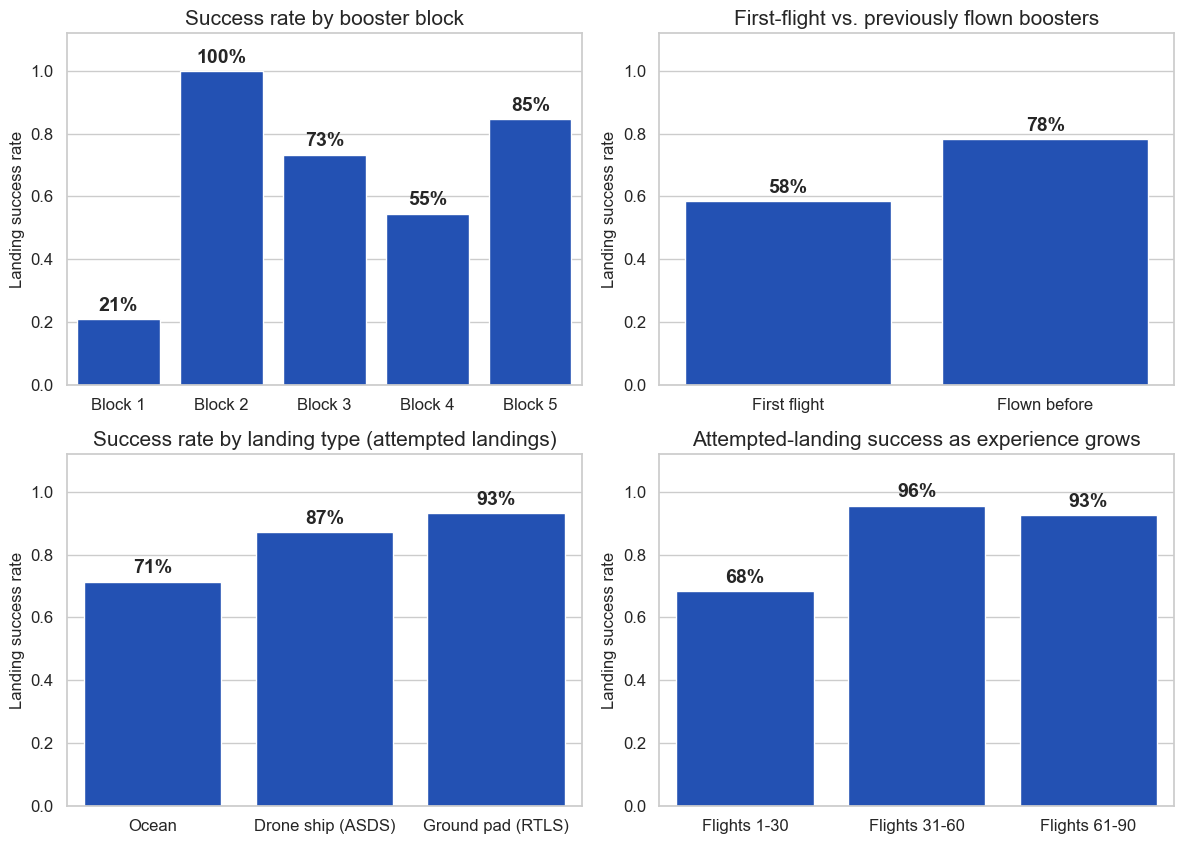

In [11]:
block_rate = df.groupby('Block')['Class'].mean().reset_index()
block_rate['Block'] = 'Block ' + block_rate['Block'].astype(int).astype(str)
reuse_rate = df.assign(Booster=np.where(df['Reused'], 'Flown before', 'First flight')).groupby('Booster')['Class'].mean().reindex(['First flight', 'Flown before']).reset_index()
landing_rate = attempted.groupby('LandingType')['Class'].mean().sort_values().reset_index()
attempted_bins = attempted.assign(Flights=pd.cut(attempted['FlightNumber'], [0, 30, 60, 90], labels=['Flights 1-30', 'Flights 31-60', 'Flights 61-90']))
experience_rate = attempted_bins.groupby('Flights', observed=True)['Class'].mean().reset_index()

fig, axes = plt.subplots(2, 2, figsize=(12, 8.6))
panels = [
    (axes[0, 0], block_rate, 'Block', 'Success rate by booster block'),
    (axes[0, 1], reuse_rate, 'Booster', 'First-flight vs. previously flown boosters'),
    (axes[1, 0], landing_rate, 'LandingType', 'Success rate by landing type (attempted landings)'),
    (axes[1, 1], experience_rate, 'Flights', 'Attempted-landing success as experience grows'),
]
for ax, data_, x, title in panels:
    sns.barplot(x=x, y='Class', data=data_, ax=ax, color='#0B49CB')
    ax.bar_label(ax.containers[0], labels=[f'{v:.0%}' for v in data_['Class']], padding=3, fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.12)
    ax.set_title(title, fontsize=15)
    ax.set_xlabel('')
    ax.set_ylabel('Landing success rate', fontsize=12)
    ax.tick_params(labelsize=12)
plt.tight_layout()
plt.savefig('images/insights_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

* Most "failures" in the label are launches where SpaceX did not try to land the booster; when a landing is attempted it succeeds about 87% of the time.
* Block 5 boosters land far more reliably than Block 1 boosters, showing the effect of hardware upgrades.
* Boosters that have flown before land more often than brand-new boosters, so reuse has not reduced reliability.
* Ground-pad landings (RTLS) succeed more often than drone-ship landings, which are used for heavier or higher-energy missions.
* Attempted-landing success rises sharply after the first 30 flights as SpaceX gains experience.

## Features Engineering

In [12]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### Task 7: Create dummy variables for categorical columns

In [13]:
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### Task 8: Cast all numeric columns to float64

In [14]:
features_one_hot = features_one_hot.astype('float64')
features_one_hot.shape

(90, 80)

In [15]:
features_one_hot.to_csv('dataset_part_3.csv', index=False)
print('Saved dataset_part_3.csv')

Saved dataset_part_3.csv
